# cd_me — desk synthesis

Huang–Ranaldo–Schrimpf–Somogyi (2021) *Constrained Dealers and Market Efficiency*.

Lib: `research.lib.cdme` · Data: **HL + Deribit** real quotes (+ Kraken **spot_l2** when dense) · **No ClickHouse MCP**.

**Board:** PIM / DCM̂ / elasticity = **Hold Monitor** · TOB-cross α = **Kill** · LSTAR/model = **Park** · `live_orders=false` · **0 Promote**.

## Certified panel status

- **Primary:** `panel_core_2venue` **n=9** — 2026-09-14…18, 25–27, 2026-10-01 ([`out/panel_completeness/`](../out/panel_completeness/))
- **Spot_l2 subpanel:** **n=4** — 2026-09-25, 26, 27, 2026-10-01
- **Retracted:** “10/10 three-venue + trade_synth” — synth **QUARANTINED** (`has_synth=false` on PIM outs)
- **Elasticity:** n=88 corr=−0.46 CI[−0.57,−0.35]; falsifiers [`out/pass2/pass2_falsifiers.json`](../out/pass2/pass2_falsifiers.json)

Chapter deep-dives:
- [`../chapters/ch00_overview/ch00_overview.ipynb`](../chapters/ch00_overview/ch00_overview.ipynb)
- [`../chapters/pim_vloop_tcost/pim_vloop_tcost.ipynb`](../chapters/pim_vloop_tcost/pim_vloop_tcost.ipynb)
- [`../chapters/dcm_proxies/dcm_proxies.ipynb`](../chapters/dcm_proxies/dcm_proxies.ipynb)
- [`../chapters/elasticity_regimes/elasticity_regimes.ipynb`](../chapters/elasticity_regimes/elasticity_regimes.ipynb)
- park: `lstar_panel`, `model_sim` · checklist: `robustness`

See [`../DESK_MEMO.md`](../DESK_MEMO.md) · [`../CHAPTER_INDEX.md`](../CHAPTER_INDEX.md) · shadow [`../applications/paper_shadow/`](../applications/paper_shadow/).


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


In [2]:

SHADOW = BOOK / "applications" / "paper_shadow" / "out"
pim = load_json(OUT / "pim_vloop_tcost" / "summary.json")
dcm = load_json(OUT / "dcm_proxies" / "summary.json")
el = load_json(OUT / "elasticity_regimes" / "summary.json")
p2 = load_json(PASS2 / "pass2_falsifiers.json") if PASS2.is_dir() else None
pim_panel = load_json(OUT / "pim_vloop_tcost" / "panel_rows.json") or []
dcm_panel = load_json(OUT / "dcm_proxies" / "panel_rows.json") or []
hourly_pim = expand_pim_hourly(pim_panel)
hourly_dcm = expand_dcm_hourly(dcm_panel)
print("pim days", None if not pim else pim.get("days"), "n_ok", None if not pim else pim.get("n_ok"),
      "venues", None if not pim else pim.get("venues"))
print("dcm n_ok", None if not dcm else dcm.get("n_ok"))
print("elasticity days", None if not el else el.get("days"))
print("pass2", PASS2.is_dir(), "promote_count", None if not p2 else (p2.get("decisions") or {}).get("promote_count"))


pim days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01'] n_ok 9 venues ['hyperliquid', 'deribit', 'kraken']
dcm n_ok 9
elasticity days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 True promote_count 0


## 1. Signal board (pinned)


In [3]:

print_board()
board = SHADOW / "SHADOW_BOARD.md"
if board.exists():
    display(Markdown(board.read_text()))


id                                 gate   note
----------------------------------------------------------------------------------------
risk.pim_cross_venue               Hold   PIM = VLOOP+|TCOST| · panel_core_2venue (HL↔Deribit real quotes); spot_l2 subpanel only
info.vloop_tcost_commonality       Hold   pooled hourly corr on certified real-quote panel (see DESK_MEMO)
info.vloop_tcost_stress_split      Hold   calm vs stress (PIM q25/q75) on certified panel
risk.dcm_pc1                       Hold   PC1 of public funding/basis/RV/imbalance proxies
info.pim_dcm_incremental           Hold   partial(PIM,DCM|RV) on certified panel — not pure RV alias
liq.elasticity_regime              Hold   corr(VLM,PIM) by DCM quantile — certified 2-venue; ceiling Hold
info.elasticity_after_rv           Hold   partial(PIM,VLM|RV) on certified panel
info.object_leadlag_map            Hold   hourly lead-lag vs mid_ret/RV/notional — descriptive map not α
info.kraken_spot_vs_2venue         Hold   spot_l2 sub

# cd_me SHADOW BOARD

**Day:** `2026-09-14` · **Primary:** `hyperliquid` `ETH`
**UTC:** 2026-10-02T09:52:22.900923+00:00

> SHADOW only · `live_orders=false` · `alpha_claim=false` · PIM/DCM = **Hold Monitor** · TOB-cross α = **Kill** · never mercat/gateway OE

## Gate labels (pinned)

| ID | Gate | Role |
|----|------|------|
| `risk.pim_cross_venue` | Hold | PIM telemetry |
| `risk.dcm_pc1` | Hold | DCM̂ regime |
| `liq.elasticity_regime` | Hold | Elasticity split |
| `info.vloop_tcost_commonality` | Hold | VLOOP↔TCOST |
| `alpha.tob_cross_arb` | Kill | Never sized |
| `risk.bank_cds_var` | Kill | Vanity |

## Monitors

- **PIM** ok=True venues=['hyperliquid', 'deribit'] n_finite=668 mean=0.015577 p50=0.000405 corr(V,T)=0.831 gate=Hold
- **DCM̂** ok=True home=deribit n_valid=291 explained=0.601 constrained_flag=True gate=Hold
- **Elasticity** ok=True source=pim_vloop_tcost_hourly all_corr=-0.320 n=13 regime_ok=False note=Hourly PIM×notional from research out/ artifact; min_n=5 exploratory Hold gate=Hold
- **TOB gaps** {'kraken': "RuntimeError: no TOB for kraken/ETH day=2026-09-14; warehouse:RuntimeError:No quote stream for kraken/PF_ETHUSD days=['2026-09-14'] (primary=l2_snapshot_level) | collector:FileNotFoundError:no collector TOB dir for 2026-09-14: /home/dev/srv/ares-startarb/results/xarb_md/tob/20260914"}

## Artifacts

- `logs/shadow.log`
- `out/events.jsonl`
- `out/shadow_meta.json`
- research `out/pim_vloop_tcost/` / `out/dcm_proxies/` (when joined)



## 2. PIM chapter findings (certified real quotes)


,day,ok,venues,n_venues,n_finite,pim_mean,vloop_mean,tcost_mean,corr_vt,cov_hl,cov_db,cov_kr,kraken
0,2026-09-14,True,"hyperliquid,deribit",2,668,0.0156,0.0070,0.0044,0.8308,0.0425,0.4933,NaN,absent_2venue
1,2026-09-15,True,"hyperliquid,deribit",2,165,0.0210,0.0109,0.0030,1.0000,0.0437,0.4901,NaN,absent_2venue
2,2026-09-16,True,"hyperliquid,deribit",2,621,0.0118,0.0061,0.0039,0.9938,0.0427,0.4731,NaN,absent_2venue
3,2026-09-17,True,"hyperliquid,deribit",2,582,0.0124,0.0061,0.0033,0.9428,0.0427,0.4964,NaN,absent_2venue
4,2026-09-18,True,"hyperliquid,deribit",2,717,0.0133,0.0070,0.0045,0.9946,0.0439,0.4851,NaN,absent_2venue
5,2026-09-25,True,"hyperliquid,deribit,kraken",3,1876,0.0282,0.0139,0.0052,0.9090,0.0431,0.4845,0.0982,spot_l2
6,2026-09-26,True,"hyperliquid,deribit,kraken",3,1863,0.0357,0.0179,0.0090,0.9020,0.0434,0.4996,0.1252,spot_l2
7,2026-09-27,True,"hyperliquid,deribit,kraken",3,914,0.0321,0.0153,0.0084,0.8448,0.0434,0.4999,0.0112,spot_l2
8,2026-10-01,True,"hyperliquid,deribit,kraken",3,1502,0.0469,0.0232,0.0071,0.9098,0.0437,0.4024,0.0571,spot_l2


kraken modes: {'absent_2venue': 5, 'spot_l2': 4}


**fig_pim_day_means.png** — `out/pim_vloop_tcost/figs/fig_pim_day_means.png`

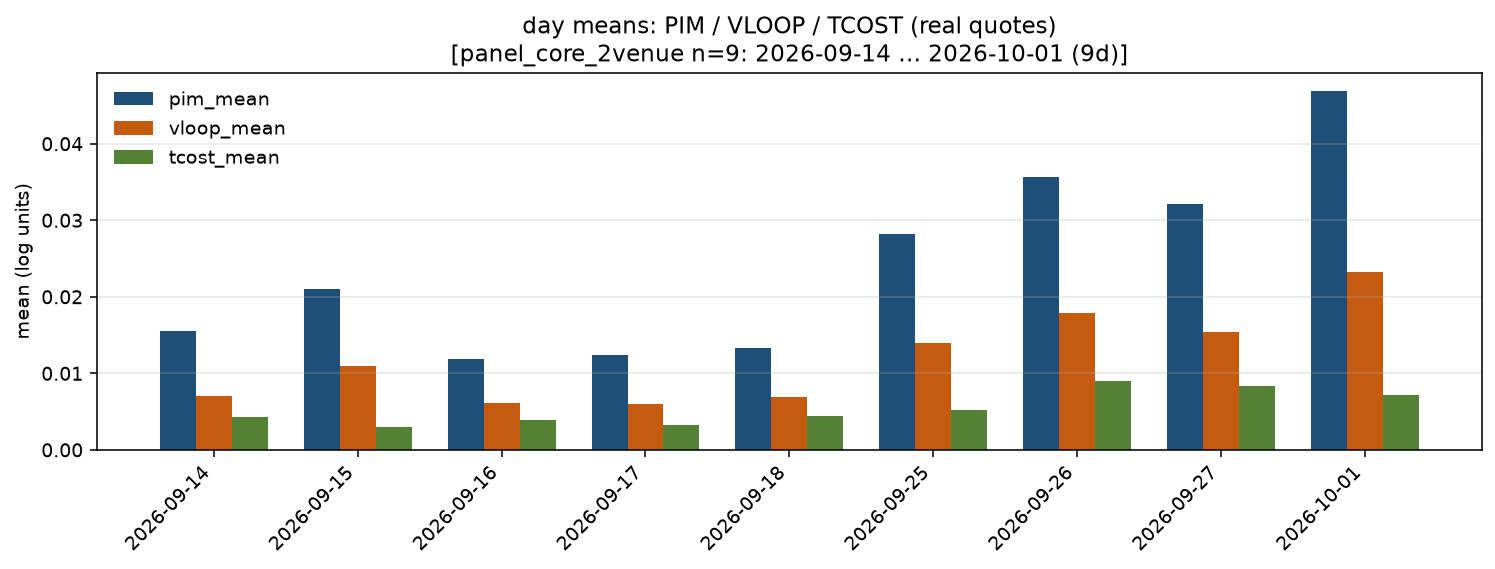

**fig_pim_hourly.png** — `out/pim_vloop_tcost/figs/fig_pim_hourly.png`

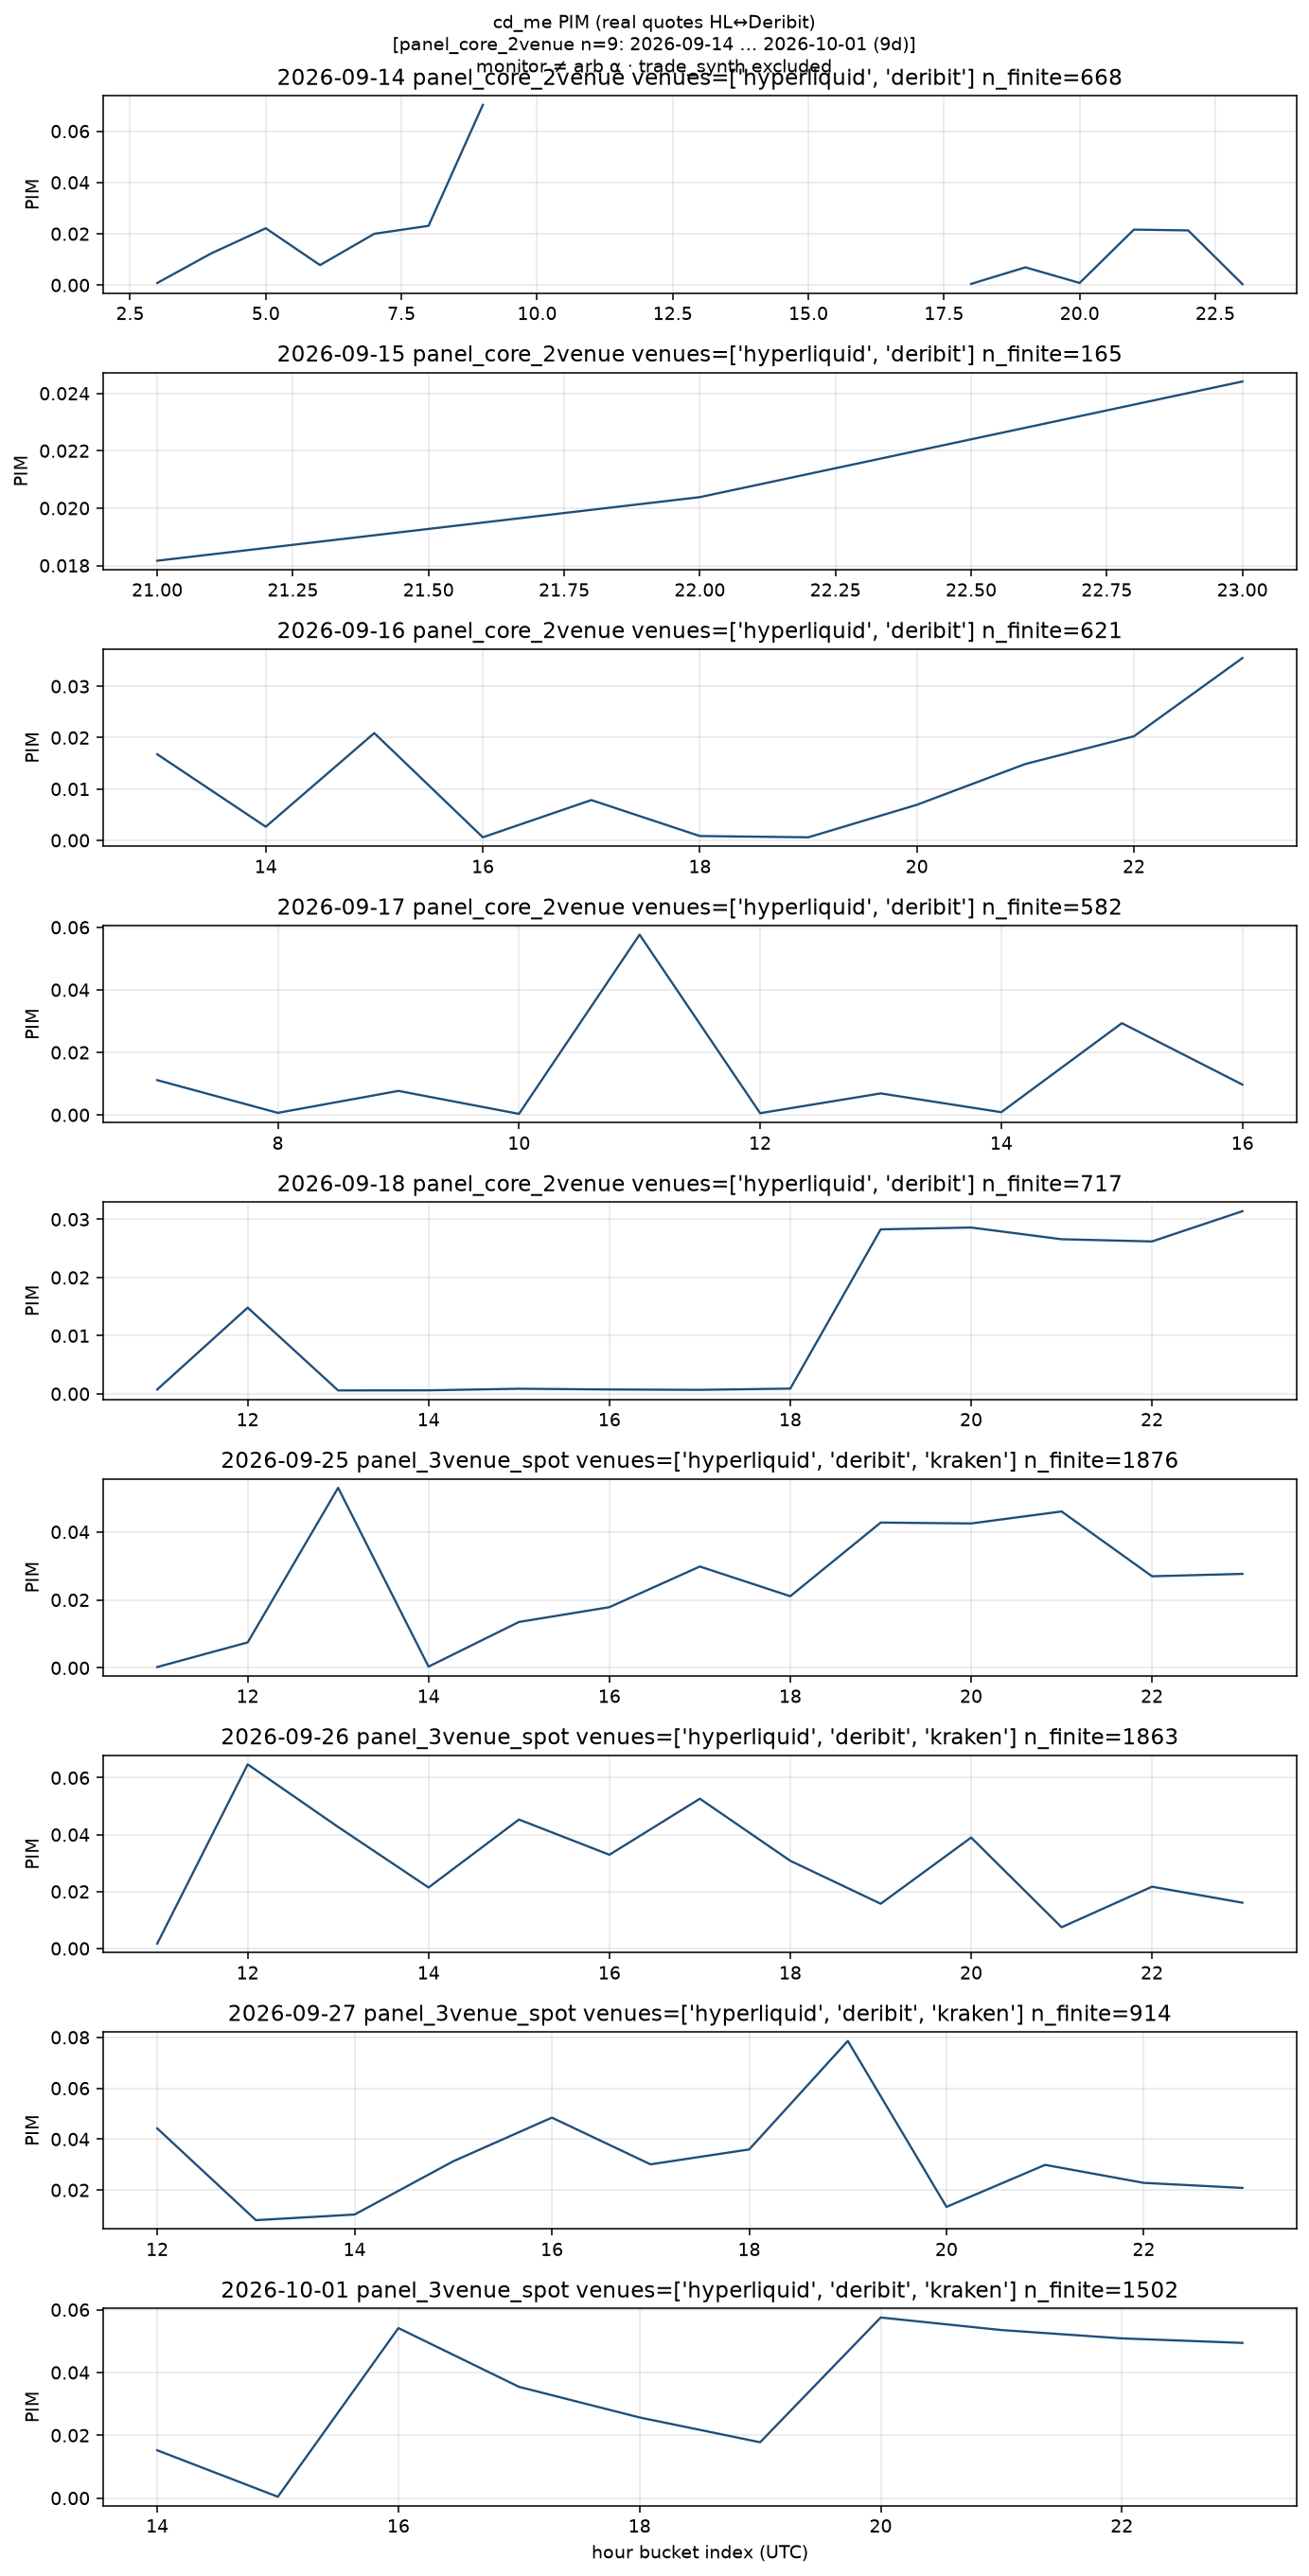

**fig_vloop_tcost_corr.png** — `out/pim_vloop_tcost/figs/fig_vloop_tcost_corr.png`

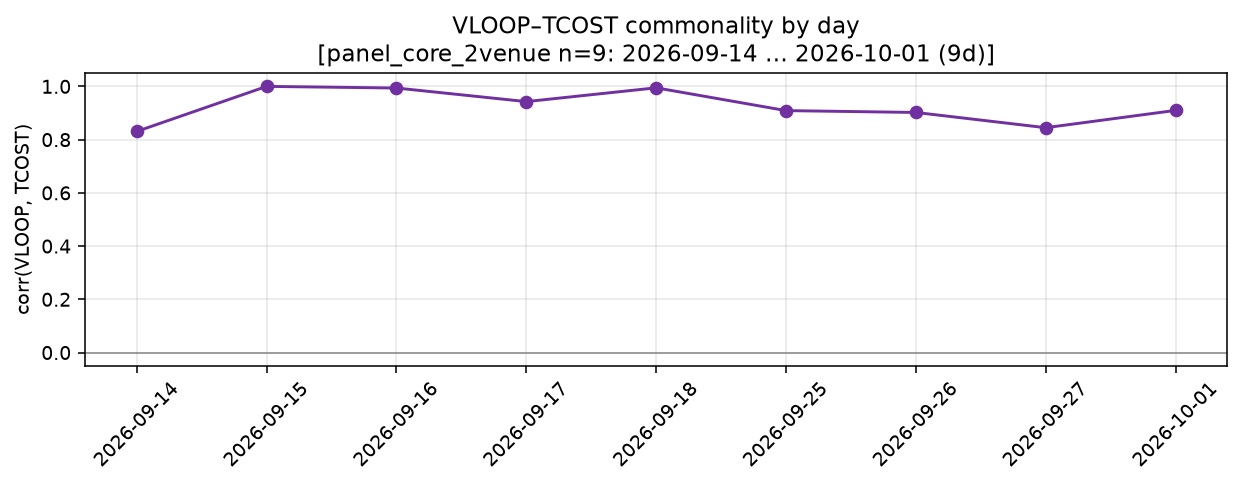

In [4]:

tbl = day_summary_table(pim_panel, inventory=KR_INV)
display(tbl.round(4))
print("kraken modes:", tbl["kraken"].value_counts().to_dict())
show_pngs(OUT / "pim_vloop_tcost" / "figs")


### Inline — ToD + VLOOP–TCOST


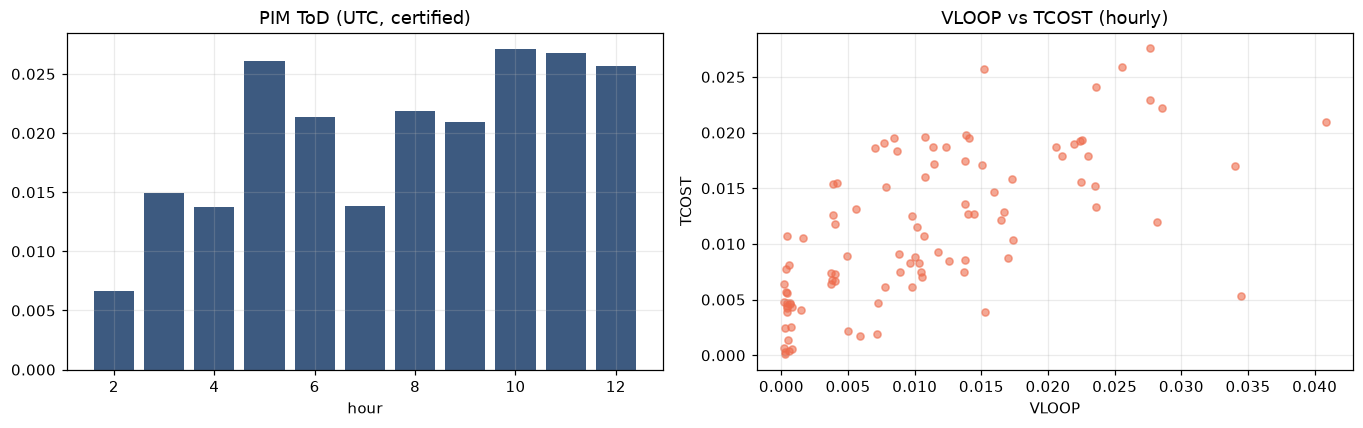

corr(V,T) 0.6673626521231802


In [5]:

h = hourly_pim
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
tod = h.groupby("hour_utc")["pim"].mean()
axes[0].bar(tod.index, tod.values, color="#3d5a80")
axes[0].set_title("PIM ToD (UTC, certified)"); axes[0].set_xlabel("hour")
ok = h[np.isfinite(h["vloop"]) & np.isfinite(h["tcost"])]
axes[1].scatter(ok["vloop"], ok["tcost"], s=22, alpha=0.6, c="#ee6c4d")
axes[1].set_xlabel("VLOOP"); axes[1].set_ylabel("TCOST"); axes[1].set_title("VLOOP vs TCOST (hourly)")
plt.tight_layout(); plt.show()
print("corr(V,T)", float(ok["vloop"].corr(ok["tcost"])) if len(ok)>2 else None)


## 3. DCM̂ findings


,day,n_valid,explained,L_fund,L_rv,L_imb
0,2026-09-14,331,0.6621,0.6959,0.6368,0.3319
1,2026-09-15,332,0.7922,0.6242,0.6231,0.4713
2,2026-09-16,330,0.6423,0.7068,0.7073,-0.0082
3,2026-09-17,333,0.9862,0.7071,0.7071,0.0000
4,2026-09-18,319,0.6567,0.7055,0.7072,-0.0455
5,2026-09-25,332,0.6595,0.7009,0.7019,-0.1268
6,2026-09-26,325,0.6661,0.7025,0.6996,0.1307
7,2026-09-27,332,0.9854,0.7071,0.7071,0.0000
8,2026-10-01,0,NaN,NaN,NaN,NaN


**fig_dcm_coverage.png** — `out/dcm_proxies/figs/fig_dcm_coverage.png`

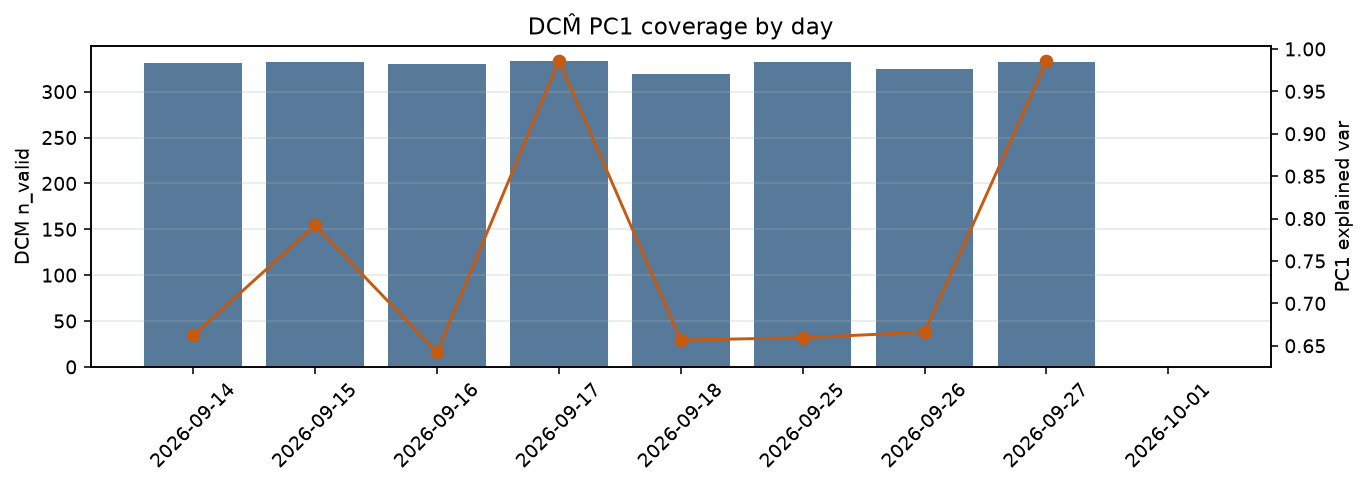

In [6]:

rows = []
for d in dcm_panel:
    meta = d.get("dcm") or {}
    load = meta.get("loadings") or {}
    rows.append({"day": d.get("day"), "n_valid": meta.get("n_valid"), "explained": meta.get("explained_var"),
                 "L_fund": load.get("abs_funding"), "L_rv": load.get("rv"), "L_imb": load.get("abs_imbalance")})
display(pd.DataFrame(rows).round(4))
show_pngs(OUT / "dcm_proxies" / "figs")


## 4. Elasticity findings


{
  "all": {
    "ok": true,
    "n": 88,
    "corr": -0.4612833556222188,
    "ci_lo": -0.5697748432382688,
    "ci_hi": -0.35269499514070435,
    "n_boot": 800
  },
  "regime": {
    "ok": true,
    "corr_low": -0.4893284681016839,
    "corr_high": -0.5955304634537502,
    "delta": -0.10620199535206626,
    "n_low": 15,
    "n_high": 26,
    "q_low": -1.5865040328978965,
    "q_high": 0.03995832935775736,
    "low_q": 0.25,
    "high_q": 0.75
  },
  "ceiling": "Hold"
}


**fig_elasticity_by_day.png** — `out/elasticity_regimes/figs/fig_elasticity_by_day.png`

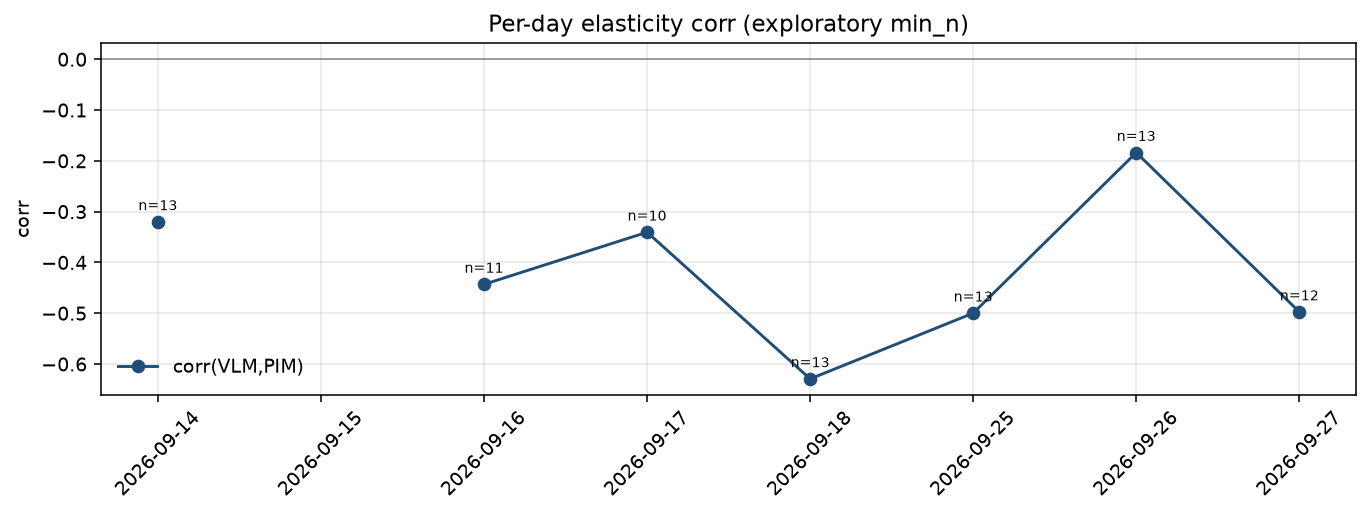

**fig_elasticity_pooled_ci.png** — `out/elasticity_regimes/figs/fig_elasticity_pooled_ci.png`

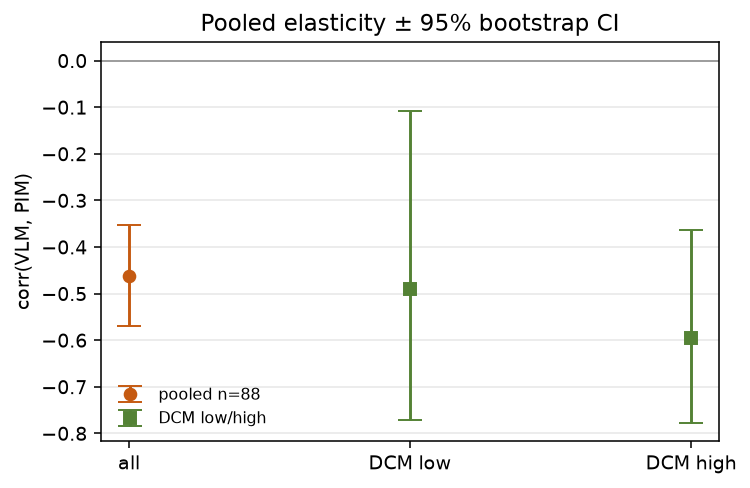

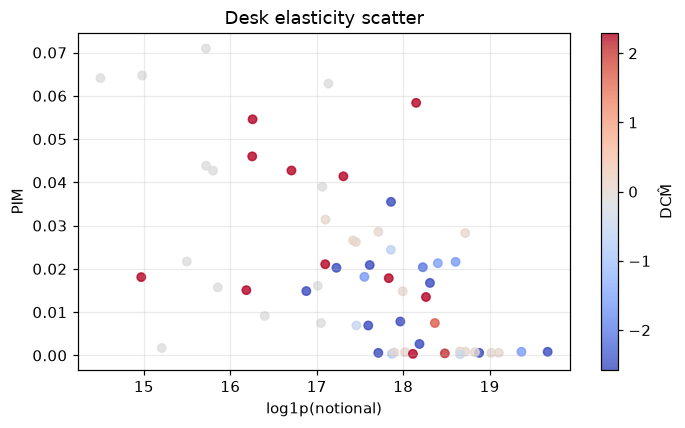

In [7]:

pooled = (el or {}).get("pooled") or {}
print(json.dumps({"all": pooled.get("all"), "regime": pooled.get("regime_point"),
                  "ceiling": pooled.get("decision_ceiling")}, indent=2, default=str))
show_pngs(OUT / "elasticity_regimes" / "figs")
ok = hourly_dcm[np.isfinite(hourly_dcm["pim"]) & np.isfinite(hourly_dcm["notional"])]
fig, ax = plt.subplots(figsize=(6.5, 4.0))
sc = ax.scatter(np.log1p(ok["notional"]), ok["pim"], c=ok["dcm"], cmap="coolwarm", s=30, alpha=0.8)
ax.set_xlabel("log1p(notional)"); ax.set_ylabel("PIM"); ax.set_title("Desk elasticity scatter")
fig.colorbar(sc, ax=ax, label="DCM̂")
plt.tight_layout(); plt.show()


## 5. Pass-2 / Kraken honesty / shadow


In [8]:

print("Kraken: dense spot_l2 only; else absent_2venue. trade_synth QUARANTINED (PROXY/NOT TOB).")
print("certified primary:", PRIMARY)
print("spot_l2 subpanel:", SPOT)
ks = (pim or {}).get("kraken_status") or []
for row in ks:
    print(f"  {row.get('day')}: {row.get('kraken_mode')} in_tob={row.get('in_tob')}")

if p2:
    print("pass2 decisions:", json.dumps(p2.get("decisions"), indent=2))
    pp = p2.get("pim_panel") or {}
    print("pass2 n_ok", pp.get("n_days_ok"), "has_synth", (pim or {}).get("has_synth"))
else:
    print("out/pass2/ not present")

meta = load_json(SHADOW / "shadow_meta.json")
print("shadow_meta", json.dumps(meta, indent=2)[:800] if meta else None)
events = SHADOW / "events.jsonl"
if events.exists():
    n = sum(1 for _ in events.open())
    print("events.jsonl lines", n)


Kraken: dense spot_l2 only; else absent_2venue. trade_synth QUARANTINED (PROXY/NOT TOB).
certified primary: ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel: ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
  2026-09-14: absent_2venue in_tob=False
  2026-09-15: absent_2venue in_tob=False
  2026-09-16: absent_2venue in_tob=False
  2026-09-17: absent_2venue in_tob=False
  2026-09-18: absent_2venue in_tob=False
  2026-09-25: spot_l2 in_tob=True
  2026-09-26: spot_l2 in_tob=True
  2026-09-27: spot_l2 in_tob=True
  2026-10-01: spot_l2 in_tob=True
pass2 decisions: {
  "risk.pim_cross_venue": "Hold",
  "info.vloop_tcost_commonality": "Hold",
  "risk.dcm_pc1": "Hold",
  "liq.elasticity_regime": "Hold",
  "promote_count": 0,
  "note": "Pass-2 falsifiers run; 0 Promote \u2014 monitors only, no TOB-cross \u03b1"
}
pass2 n_ok 9 has_synth False
shadow_meta {
  "ok": true,
  "day": "2026-09-14",
  

## 5b. Companion synthesis figs (`out/desk_synthesis/figs/`)


**fig_day_pim_means_certified.png** — `out/desk_synthesis/figs/fig_day_pim_means_certified.png`

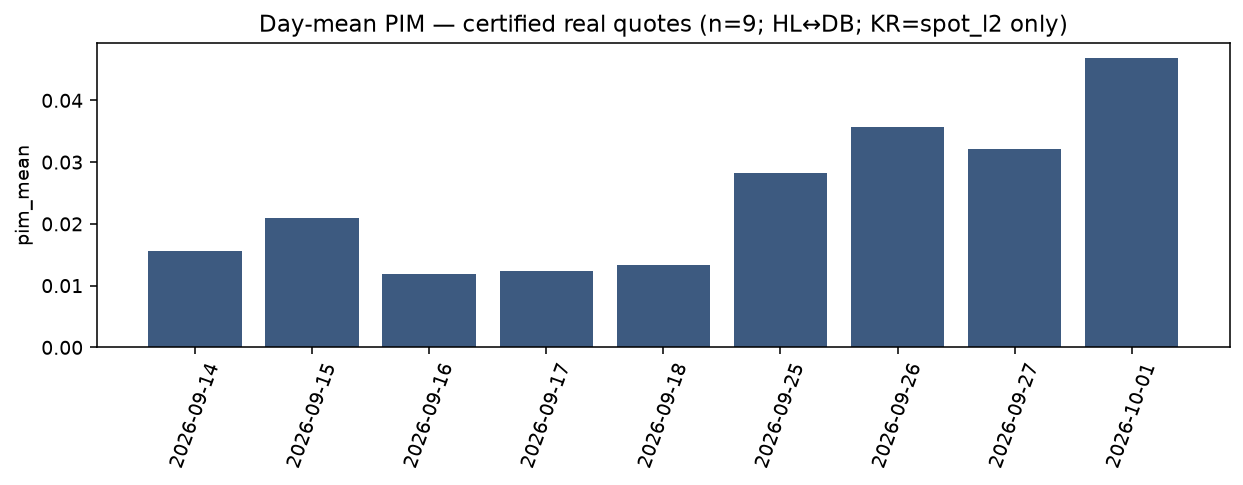

**fig_day_pim_means_synth.png** — `out/desk_synthesis/figs/fig_day_pim_means_synth.png`

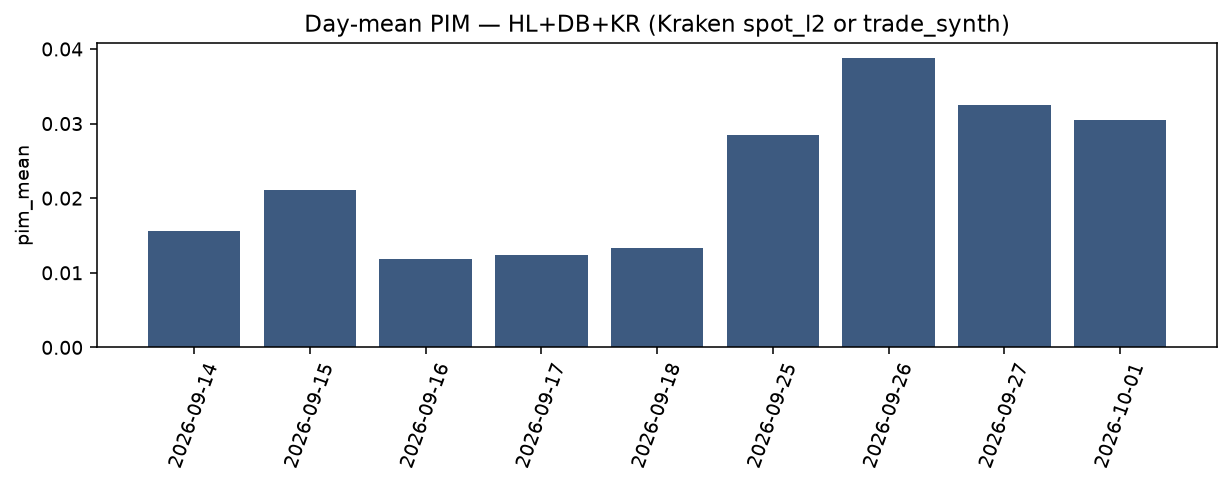

**fig_elasticity_scatter.png** — `out/desk_synthesis/figs/fig_elasticity_scatter.png`

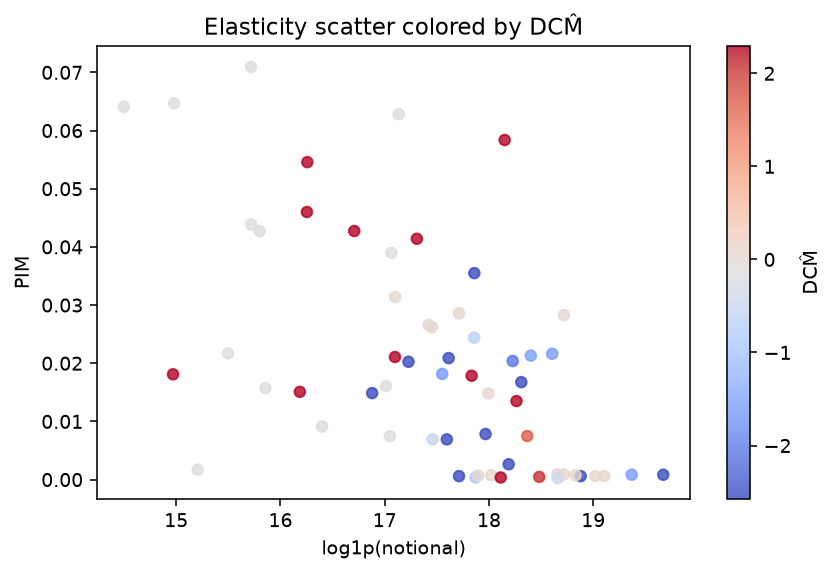

**fig_pim_tod.png** — `out/desk_synthesis/figs/fig_pim_tod.png`

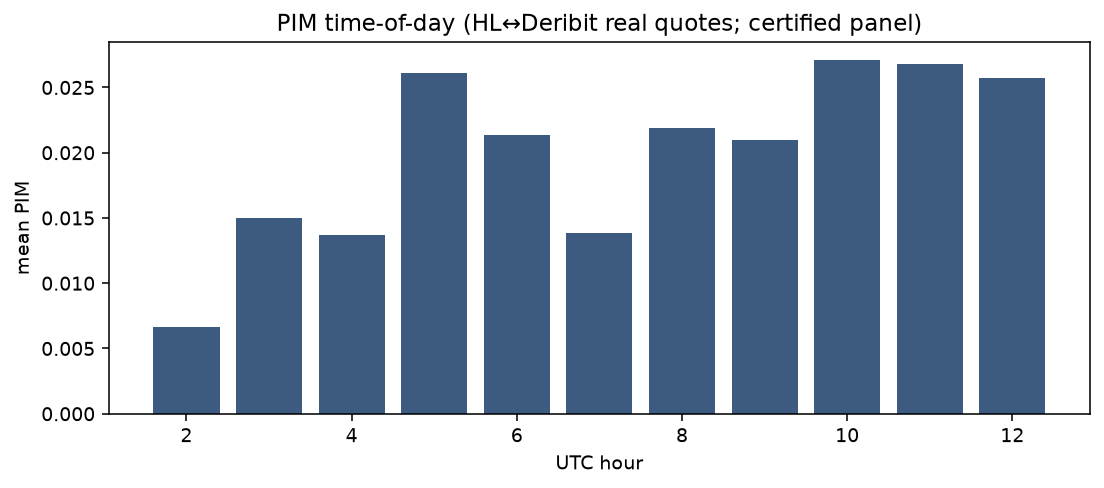

**fig_vloop_tcost_scatter.png** — `out/desk_synthesis/figs/fig_vloop_tcost_scatter.png`

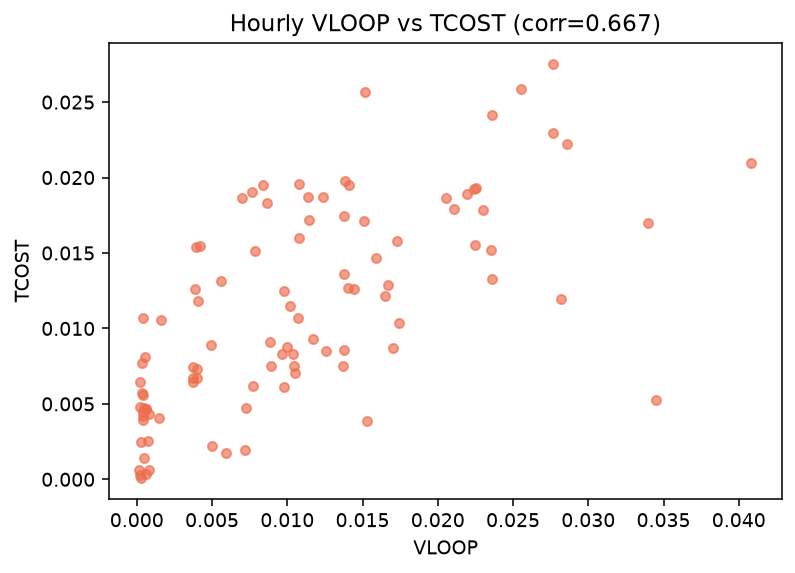

**signal_board.png** — `out/desk_synthesis/figs/signal_board.png`

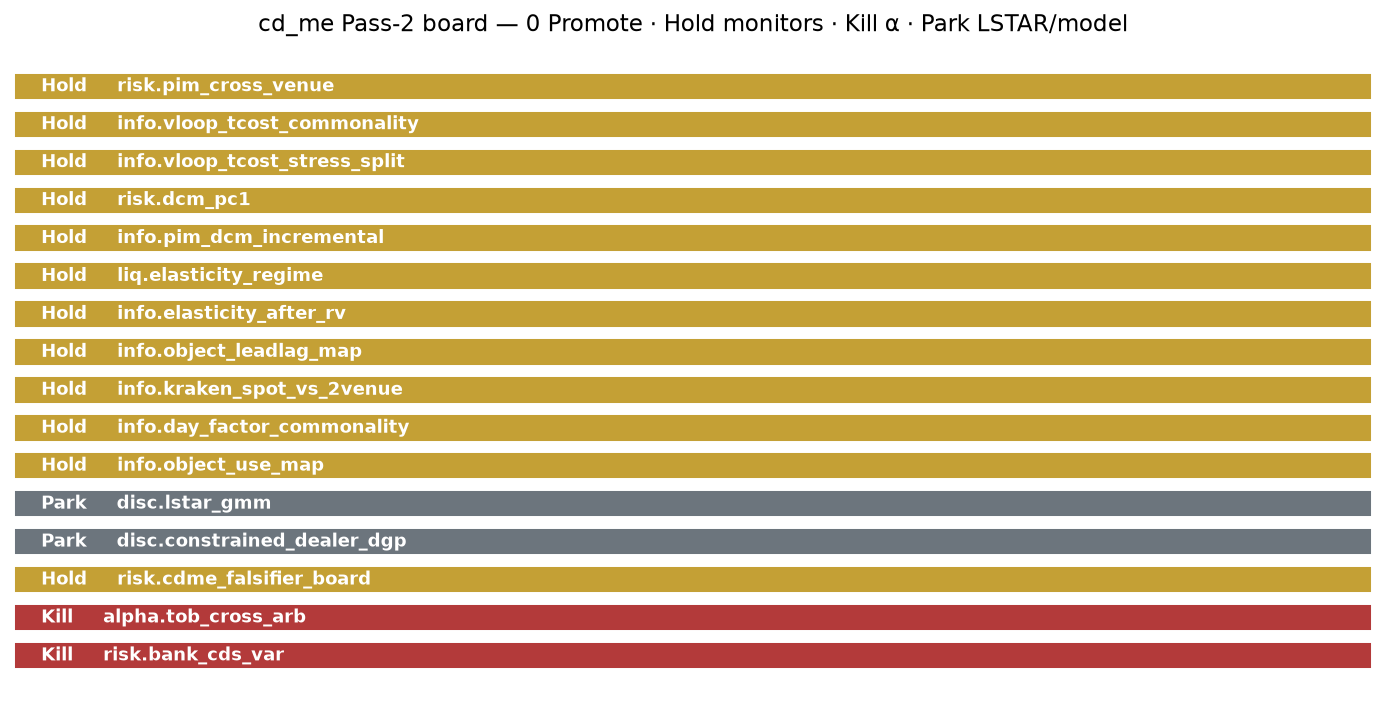

In [9]:

show_pngs(OUT / "desk_synthesis" / "figs")


## 6. Honesty

- Scoreboard = **monitor telemetry**, not PnL alpha  
- Primary = HL↔Deribit real quotes; Kraken spot_l2 secondary; `trade_synth` **QUARANTINED**  
- Negative crypto elasticity corr ≠ soft-Promote of paper FX result  
- 0 Promote · Hold monitors · Kill TOB-cross α · Park LSTAR/model


In [10]:

print_board()
print("\\nChapter notebooks ready under chapters/*/ — see CHAPTER_INDEX notebook section.")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.pim_cross_venue               Hold   PIM = VLOOP+|TCOST| · panel_core_2venue (HL↔Deribit real quotes); spot_l2 subpanel only
info.vloop_tcost_commonality       Hold   pooled hourly corr on certified real-quote panel (see DESK_MEMO)
info.vloop_tcost_stress_split      Hold   calm vs stress (PIM q25/q75) on certified panel
risk.dcm_pc1                       Hold   PC1 of public funding/basis/RV/imbalance proxies
info.pim_dcm_incremental           Hold   partial(PIM,DCM|RV) on certified panel — not pure RV alias
liq.elasticity_regime              Hold   corr(VLM,PIM) by DCM quantile — certified 2-venue; ceiling Hold
info.elasticity_after_rv           Hold   partial(PIM,VLM|RV) on certified panel
info.object_leadlag_map            Hold   hourly lead-lag vs mid_ret/RV/notional — descriptive map not α
info.kraken_spot_vs_2venue         Hold   spot_l2 sub